# RV DeepSDF Training (Task 4.5 / 4.6 / 4.7)

**Status: final technical pilot plus first held-out patient check (2026-08-24).**
The active path is the production-coordinate `production_lps_v2` corpus. The
15-shape RV pilot was trained for 300 CUDA epochs, decoded to watertight meshes,
and loaded strictly into the production decoder without writing any file under
`COS40005FYPA`.

Measured final-pilot evidence:
- final training loss: 0.01544;
- 15/15 training-shape SDF gates passed, with mean sign accuracy 90.20%;
- 15/15 64-grid decoded meshes were watertight;
- training-shape technical metric: Chamfer RMS 1.51 +/- 0.22 mm, Hausdorff
  5.01 +/- 0.81 mm;
- held-out patient representation pilot: train on 12 shapes, then fit a fresh
  shape code for three unseen patients. All 3/3 decoded meshes were watertight,
  with mean Chamfer RMS 2.31 mm and HD95 4.92 mm.

The held-out check uses an expert segmentation SDF to fit the new latent code.
It tests whether the learned RV shape space can represent a new patient. It is
not MRI-to-segmentation accuracy, clinical accuracy, or a final large-scale test.
Section 8 records the remaining work honestly.

## Task 4.5 is resolved: the upstream trainer exists

The upstream repository ships `train_4dmm.py`, `process_data.py`,
`reconstruct_4dmm.py`, config files and trained ACDC checkpoints (endo, epi).
This notebook prepares RV data in the upstream format and invokes the upstream
trainer rather than reimplementing its loss functions.


## 1. The two decoders are checkpoint-compatible (verified)Production and upstream ship **different source files for the same network**:| | production | upstream ||---|---|---|| file | `app/dependencies/networks/decoder.py` | `networks/4dmm_decoder.py` || `NetworkArch` | `"decoder"` | `"4dmm_decoder"` || specs kwargs | `motionmodel_kargs` / `shapemodel_kargs` | `motionnet_kargs` / `shapenet_kargs` || classes | `MotionModel` / `ShapeModel` | `MotionNet` / `ShapeNet` || tensor layout | flat `[M,3]`, per-point `t`/codes | batched `[b,N,3]`, per-sample `t`/codes || deformation scatter | Python loop over points (`decoder.py:163`) | `index_select` / `index_copy` |What matters is that **both assign `self.motion_net` and `self.shape_net`**, and the layerattribute names (`fc0..fc5`, `lin0..lin8`) are identical. `state_dict()` keys therefore matchexactly. Upstream's file even carries the comment *"Retain the original attribute layout;ModuleList would alter checkpoint keys"* — the compatibility is deliberate, not accidental.Confirmed by inspecting `examples/acdc/4DMM/endo/ModelParameters/latest.pth`:`{"epoch": 44, "model_state_dict": ...}`, 38 tensors, keys `motion_net.fc0.weight` ...`shape_net.lin8.bias`, **8.68 MB** — matching the 8.69 MB of production's`fourd_model_epoch_250.pth`.**Consequence:** a checkpoint trained by the upstream trainer loads into the production`FourDReconstructionHandler` unmodified. The differing `NetworkArch` / kwarg names live onlyin `specs.json`, and production supplies its own via `_get_default_specs()`.**This was executed, not assumed.** Building production's `Decoder` from production's ownspecs and calling `load_state_dict(strict=True)` on upstream's shipped `endo` checkpointsucceeds (epoch 44), and a forward pass returns `coords [16,3]`, `sdf [16,1]`. Section 7keeps the check runnable so it can be re-run against the RV checkpoint.

## 2. Two findings that change the plan### 2a. Production inference never runs the motion model`_transform_to_canonical_in_memory` returns a hardcoded `'t': 0.0`(`fourdreconstruction_handler.py:451`). That flows into `_optimize_latent_codes_sync`, whichbuilds an all-zero `t` and calls `decoder(xyz, t, c_m, c_s)`. Inside `Decoder.Deformation`:    index_nonED = torch.nonzero(t).squeeze().tolist()Empty for all-zero `t`, so `motion_net` is never evaluated. Each frame is insteadreconstructed independently by re-optimizing its own `c_s`(`_predict_4d_sequence` loops frames, calling `_optimize_latent_codes_sync` per frame).**Confirmed by execution, not only by reading:** calling the production `Decoder` with`t = zeros(16)` returns coordinates *bit-identical* to its input(`torch.equal(new_xyz, xyz) -> True`). The deformation branch is genuinely dead on this path.So a 4D checkpoint stays loadable and correct under the current inference path — `shape_net`is exercised normally, `motion_net` is simply unused — but the temporal coherence the modelis trained for is unreachable without an inference-side change (feed real `t`, one `c_s` persequence, one `c_m` per frame). Upstream's `reconstruct_4dmm.py` shows what that path lookslike. This is a new integration task, adjacent to the deferred 4.13-4.15, and should go tothe team: per-frame independent `c_s` is exactly what produces frame-to-frame jitter.### 2b. Variable-length sequences are supported upstreamProduction's bundled `deep_sdf/dataset.py` is an **older** revision: `SDFSamples` there isper-sequence, `torch.stack`s all frames, and needs a constant frame count. Upstream's isper-frame and manifest-driven (docstring: *"Dataset helpers for variable-length cardiacsequences"*), with `c_m = Embedding(len(dataset))` indexed globally and `frame_num` read fromeach sequence's `instance_list`.So patients with differing frame counts need **no temporal resampling**. patient005's 30frames and the LV default's 25 can sit in one corpus. Use the upstream dataset, not thebundled one.

## 3. Configuration

In [1]:
from pathlib import Path
import os, sys, json

def find_notebook_root():
    configured = os.environ.get("VISHEART_RV4D_ROOT")
    candidates = [Path(configured).expanduser()] if configured else []
    candidates += [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "rv_deepsdf_training.ipynb").is_file():
            return candidate
    raise RuntimeError("Set VISHEART_RV4D_ROOT to the directory containing rv_deepsdf_training.ipynb.")

def required_directory(name):
    value = os.environ.get(name)
    if not value:
        raise RuntimeError(f"{name} is required on this machine.")
    path = Path(value).expanduser().resolve()
    if not path.is_dir():
        raise RuntimeError(f"{name} is not a directory: {path}")
    return path

NB_ROOT = find_notebook_root()
REPO_ROOT = required_directory("VISHEART_PROJECT_ROOT")
INFER_ROOT = REPO_ROOT / "cardiac-component-segmentation-ai" / "visheart-inference-gpu"
DEPS_DIR = INFER_ROOT / "app" / "dependencies"
if not (DEPS_DIR / "get_P.py").is_file():
    raise RuntimeError(f"Cannot find get_P.py under {DEPS_DIR}")
UPSTREAM_DIR = required_directory("VISHEART_4DMM_ROOT")
if not (UPSTREAM_DIR / "train_4dmm.py").is_file():
    raise RuntimeError(f"Not an upstream 4DMM checkout: {UPSTREAM_DIR}")
raw_masks = os.environ.get("VISHEART_RV4D_MASKS", "")
MASK_PATHS = [Path(item).expanduser().resolve() for item in raw_masks.split(os.pathsep) if item]
SURFACE = "rv"
CORPUS_VERSION = "production_lps_v2"
PROC_ROOT = UPSTREAM_DIR / "training_data" / f"processed_{SURFACE}_{CORPUS_VERSION}"
MANIFEST = UPSTREAM_DIR / "training_data" / f"data_load_{SURFACE}_{CORPUS_VERSION}.json"
RV_GRID_BOUND = float(os.environ.get("VISHEART_RV4D_GRID_BOUND", "2.25"))
EXP_DIR = UPSTREAM_DIR / "examples" / "acdc" / "4DMM" / SURFACE
RV_LABEL, LVM_LABEL = 1, 2
MARCHING_CUBES_LEVEL, MIN_COMPONENT_VOXELS, SMOOTHING_ITERATIONS = 0.5, 32, 1
SDF_SAMPLE_COUNT = int(os.environ.get("VISHEART_RV4D_SDF_SAMPLE_COUNT", "250000"))
SURFACE_SAMPLE_COUNT = int(os.environ.get("VISHEART_RV4D_SURFACE_SAMPLE_COUNT", "10000000"))
NORMAL_SAMPLE_COUNT, ED_INDEX = 5, int(os.environ.get("VISHEART_RV4D_ED_INDEX", "0"))
RUN_SMOKE_TEST = os.environ.get("VISHEART_RV4D_RUN_SMOKE", "").lower() == "true"
CONFIGURE_UPSTREAM = os.environ.get("VISHEART_RV4D_CONFIGURE_UPSTREAM", "").lower() == "true"
print({"notebook_root": str(NB_ROOT), "mask_count": len(MASK_PATHS), "upstream": str(UPSTREAM_DIR)})

{'notebook_root': 'E:\\Jy\\visheart-rv-4d-notebook', 'mask_count': 0, 'upstream': 'E:\\Jy\\4DMM-upstream'}


In [2]:
# Production is imported read-only only for get_T. SDF sampling is loaded lazily for corpus builds.
if str(DEPS_DIR) not in sys.path:
    sys.path.insert(0, str(DEPS_DIR))
import types
import numpy as np
import trimesh
import nibabel as nib
import SimpleITK as sitk
from skimage import measure
from scipy import ndimage

def transformation(mat, ver3D):
    """Upstream mesh_to_sdf coordinate transform, kept renderer-independent for audits."""
    ver3D = np.asarray(ver3D)
    if ver3D.ndim == 1:
        ver3D = np.expand_dims(ver3D, axis=1)
    ver4D = np.ones((4, ver3D.shape[1]))
    ver4D[:3, :] = ver3D[:3, :]
    return (np.asarray(mat) @ ver4D)[:3, :].T

def ComputeNormalizationParameters(vertices):
    vertices = np.asarray(vertices, dtype=float)
    center = (vertices.max(axis=0) + vertices.min(axis=0)) / 2
    maximum = np.linalg.norm(vertices - center, axis=1).max()
    return -center, 1.0 / maximum

# Prefer the unchanged production import. The shim is retained only for audit-only
# environments where its renderer stack is unavailable.
try:
    from get_P import get_T
    GET_T_RENDERER_SHIM = False
except ModuleNotFoundError as import_error:
    _mesh_package = types.ModuleType("mesh_to_sdf")
    _mesh_module = types.ModuleType("mesh_to_sdf.mesh_to_sdf")
    _mesh_module.ComputeNormalizationParameters = ComputeNormalizationParameters
    _mesh_module.transformation = transformation
    _mesh_package.mesh_to_sdf = _mesh_module
    sys.modules["mesh_to_sdf"] = _mesh_package
    sys.modules["mesh_to_sdf.mesh_to_sdf"] = _mesh_module
    from get_P import get_T
    GET_T_RENDERER_SHIM = True
    print(f"get_T renderer shim enabled: {import_error}")

try:
    import torch
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("torch", torch.__version__, "| device:", DEVICE)
except ModuleNotFoundError:
    torch, DEVICE = None, None
    print("PyTorch is unavailable in this environment: corpus auditing is supported, training is not.")
print("get_T renderer shim:", GET_T_RENDERER_SHIM)


torch 2.5.1+cu121 | device: cuda
get_T renderer shim: False


## 4. Build the RV training corpus

Target format, from upstream process_data.py:

- one NPZ per frame with pos, neg, t, P, Pi, offset, and scale;
- pos holds points with positive SDF and neg holds points with negative SDF;
- upstream assigns time by phase index only when it receives already-prepared
  contiguous phase meshes.

### Upstream precedent, verified by code read

process_data.py does not propagate ACDC ED/ES labels or derive missing phases.
It discovers already-prepared contiguous 00-surface.obj, 01-surface.obj, and
later meshes per patient, then only converts them to SDF archives. It therefore
does not justify inventing an ED/ES temporal sequence from public expert labels.

RV uses a truthful shape-set deviation: every labelled expert frame is an
independent one-frame unit with t = 0.0. This preserves real shape supervision
and does not claim unsupported patient motion.

P and Pi come from the read-only production get_T transform. The real
world-to-canonical-to-world residual was executed: maximum 1.42e-13 mm for
ACDC and 5.55e-14 mm for M&Ms/M&Ms-2. The final millimetre evaluation below
confirms reconstructed meshes return to the same world-space convention.


In [3]:
import tempfile, shutil


def load_label_volume(nifti_path):
    img = nib.load(str(nifti_path))
    data = np.asarray(img.dataobj)
    if data.ndim != 4:
        raise ValueError(f"expected 4D (X,Y,Z,T), got {data.shape}")
    return data, img.affine


def keep_main_component(binary, min_voxels=MIN_COMPONENT_VOXELS):
    lab, n = ndimage.label(binary)
    if n == 0:
        return binary
    sizes = ndimage.sum(binary, lab, range(1, n + 1))
    keep = np.arange(1, n + 1)[sizes >= min_voxels]
    if keep.size == 0:
        keep = np.array([int(np.argmax(sizes)) + 1])
    return np.isin(lab, keep)


def frame_to_mesh(vol_frame, affine):
    # Same pipeline as the validated baseline notebook (Task 4.3).
    binary = keep_main_component(vol_frame == RV_LABEL)
    binary = ndimage.binary_closing(binary, iterations=1)
    if binary.sum() < MIN_COMPONENT_VOXELS:
        return None
    padded = np.pad(binary.astype(np.float32), 1, mode="constant")
    verts, faces, _, _ = measure.marching_cubes(padded, level=MARCHING_CUBES_LEVEL)
    verts -= 1.0
    world = (np.c_[verts, np.ones(len(verts))] @ affine.T)[:, :3]   # NIfTI world coords
    mesh = trimesh.Trimesh(vertices=world, faces=faces, process=False)
    if SMOOTHING_ITERATIONS > 0:
        trimesh.smoothing.filter_taubin(mesh, iterations=SMOOTHING_ITERATIONS)
    return mesh


def production_lps_mesh(nifti_path):
    """Build the RV mesh in the exact SimpleITK/LPS coordinate basis used by production."""
    image = sitk.ReadImage(str(nifti_path))
    labels_zyx = sitk.GetArrayFromImage(image)
    if labels_zyx.ndim != 3:
        raise ValueError(f"expected a 3D NIfTI frame, got {labels_zyx.shape}")
    labels = labels_zyx.transpose(2, 1, 0).astype(np.int16, copy=False)
    binary = keep_main_component(labels == RV_LABEL)
    binary = ndimage.binary_closing(binary, iterations=1)
    if binary.sum() < MIN_COMPONENT_VOXELS:
        return labels, None
    padded = np.pad(binary.astype(np.float32), 1, mode="constant")
    vertices, faces, _, _ = measure.marching_cubes(padded, level=MARCHING_CUBES_LEVEL)
    vertices -= 1.0
    lps_to_world = np.eye(4)
    lps_to_world[:3, :3] = (
        np.asarray(image.GetDirection(), dtype=float).reshape(3, 3)
        * np.asarray(image.GetSpacing(), dtype=float)
    )
    lps_to_world[:3, 3] = np.asarray(image.GetOrigin(), dtype=float)
    world = (np.c_[vertices, np.ones(len(vertices))] @ lps_to_world.T)[:, :3]
    mesh = trimesh.Trimesh(vertices=world, faces=faces, process=False)
    if SMOOTHING_ITERATIONS > 0:
        trimesh.smoothing.filter_taubin(mesh, iterations=SMOOTHING_ITERATIONS)
    return labels, mesh


def canonical_from_nifti_frame(nifti_path):
    # Copy original NIfTI bytes, matching the production handler path exactly.
    with tempfile.TemporaryDirectory() as tmp:
        patient_dir = Path(tmp) / "patient001"
        patient_dir.mkdir()
        filename = Path(nifti_path).name
        shutil.copy2(nifti_path, patient_dir / filename)
        T, offset, scale = get_T(tmp, "acdc", "patient001", filename)
    Ti = np.identity(4)
    Ti[0:3, 0:3] = np.linalg.inv(T[0:3, 0:3])
    Ti[0:3, 3] = -np.dot(np.linalg.inv(T[0:3, 0:3]), T[0:3, 3])
    return T, Ti, np.asarray(offset).reshape(3), float(np.asarray(scale).reshape(-1)[0])


def to_canonical(mesh, T, offset, scale):
    v = (transformation(T, mesh.vertices.transpose()) + offset) * scale
    return trimesh.Trimesh(vertices=v, faces=mesh.faces, process=False)

print("helpers defined")

helpers defined


In [4]:
def build_sequence(nifti_path, seq_name, ed_index=ED_INDEX):
    PROC_ROOT.mkdir(parents=True, exist_ok=True)
    vol4d, affine = load_label_volume(nifti_path)
    n_src = vol4d.shape[3]

    # Rotate so ED is phase 0 => t == 0 marks ED, which is what Deformation keys off.
    order = [(ed_index + i) % n_src for i in range(n_src)]

    # Canonical frame is computed ONCE, from ED, and reused for every phase. Recomputing per
    # frame would let the canonical pose absorb the deformation the motion model must learn.
    # NOTE (4.1b, still open): get_T derives pose from LVM(2) and needs LV labels present in
    # the volume -- it is not RV-only. A mask with RV but no LVM will raise here. The
    # geometric baseline never exercised this path; this is the first code that does.
    raise RuntimeError(
        "The legacy in-memory temporal builder is disabled by the production-coordinate v2 contract. "
        "Use the Section 4A expert-label shape-set builder, which preserves source NIfTI geometry."
    )

    written = []
    for phase, src_i in enumerate(order):
        mesh = frame_to_mesh(vol4d[..., src_i], affine)
        if mesh is None:
            print(f"  [skip] phase {phase} (src {src_i}): empty RV"); continue
        if not mesh.is_watertight:
            print(f"  [WARN] phase {phase} (src {src_i}): NOT watertight -> skipped"); continue

        cmesh = to_canonical(mesh, T, offset, scale)
        np.random.seed((hash((seq_name, phase)) & 0x7FFFFFFF) % (2**32 - 1))
        pts, sdf = sample_sdf_near_surface(
            cmesh,
            number_of_points=SDF_SAMPLE_COUNT,
            sampling_type="sphere",
            surface_point_method="sample",
            sign_method="normal",
            scan_count=0,
            scan_resolution=0,
            sample_point_count=SURFACE_SAMPLE_COUNT,
            normal_sample_count=NORMAL_SAMPLE_COUNT,
            min_size=0,
            return_gradients=False,
            test_sampling=False,
        )
        pos = np.column_stack((pts[sdf > 0], sdf[sdf > 0])).astype(np.float32)
        neg = np.column_stack((pts[sdf < 0], sdf[sdf < 0])).astype(np.float32)
        if len(pos) == 0 or len(neg) == 0:
            print(f"  [WARN] phase {phase}: degenerate signs "
                  f"(pos={len(pos)}, neg={len(neg)}) -> skipped"); continue

        t_val = np.float32(phase / max(len(order) - 1, 1))
        out = PROC_ROOT / f"{seq_name}_{phase:02d}-{SURFACE}.npz"
        np.savez_compressed(out, pos=pos, neg=neg, t=t_val, P=T, Pi=Ti,
                            offset=np.asarray(offset).reshape(-1),
                            scale=np.asarray(scale).reshape(-1))
        written.append(out)

    print(f"  wrote {len(written)}/{n_src} frames")
    return written


sequences = {}
for p in MASK_PATHS:
    name = Path(p).name.split(".")[0]
    sequences[name] = build_sequence(p, seq_name=name)

# Week 1 eligibility audit: a T=1 file is excluded before it can masquerade as a motion sequence.
def audit_mask(mask_path):
    row = {"patient": Path(mask_path).name, "exists": Path(mask_path).is_file(), "shape": None,
           "frame_count": 0, "single_frame": False, "rv_nonempty_frames": 0,
           "usable_sequence": False, "exclusion_reason": None}
    if not row["exists"]:
        row["exclusion_reason"] = "missing input file"
        return row
    volume, _ = load_label_volume(mask_path)
    row["shape"] = tuple(int(v) for v in volume.shape)
    row["frame_count"] = int(volume.shape[3])
    row["single_frame"] = row["frame_count"] == 1
    row["rv_nonempty_frames"] = int(sum(np.any(volume[..., index] == RV_LABEL) for index in range(row["frame_count"])))
    if row["single_frame"]:
        row["exclusion_reason"] = "single-frame input: no temporal signal for motion model"
    elif row["rv_nonempty_frames"] < 2:
        row["exclusion_reason"] = "fewer than two RV-populated frames"
    else:
        row["usable_sequence"] = True
    return row

audits = [audit_mask(path) for path in MASK_PATHS]
print("patient | shape | T | single_frame | RV-populated | usable_sequence | reason")
for row in audits:
    print(f"{row['patient']} | {row['shape']} | {row['frame_count']} | {row['single_frame']} | {row['rv_nonempty_frames']} | {row['usable_sequence']} | {row['exclusion_reason'] or '-'}")
print("Usable multi-frame sequences:", sum(row["usable_sequence"] for row in audits))
print("Single-frame exclusions:", [row["patient"] for row in audits if row["single_frame"]] or "none")


patient | shape | T | single_frame | RV-populated | usable_sequence | reason
Usable multi-frame sequences: 0
Single-frame exclusions: none


In [5]:
# Legacy temporal manifest (kept for the negative T=1 audit above). The shape-set builder below writes the RV manifest only after SDF sign gates pass.
if sequences:
    manifest = {"train": {"training": {}}, "test": {}}
    for name, files in sequences.items():
        manifest["train"]["training"][name] = {"instance_list": [f.resolve().relative_to(UPSTREAM_DIR.resolve()).as_posix() for f in files]}
    MANIFEST.parent.mkdir(parents=True, exist_ok=True)
    MANIFEST.write_text(json.dumps(manifest, indent=2) + "\n")
    print(f"{MANIFEST}: {len(sequences)} legacy sequence(s)")
else:
    print("Legacy sequence builder disabled: use Section 4A for independent ED/ES shapes.")


Legacy sequence builder disabled: use Section 4A for independent ED/ES shapes.


## 4A. Public expert-label shape-set corpus

Each labelled ED/ES NIfTI is an **independent shape**, not a synthetic two-frame sequence. The manifest therefore uses one minimal sequence per shape, with one `instance_list` entry and `t = 0.0`. This permits an Option-A trainer smoke test while deliberately supplying no temporal signal.

Set `VISHEART_RV4D_DATA_ROOT` to the directory containing `training-acdc`, `Training-mms`, and `Training-mms2`. This cell reads the production data tree only; generated `.npz` files and the manifest are written under `VISHEART_4DMM_ROOT`. `VISHEART_RV4D_BUILD_CORPUS=true` is required before SDF archives are written.

The sign gate is independent of `mesh_to_sdf`: immediately after sampling, `cmesh.contains(points)` supplies the expected inside/outside relation. A mismatch above 0.5% is warned and a mismatch above 5% skips the shape. Thresholds are fixed by the Week-2 gate.


In [6]:
from collections import Counter

DATA_ROOT = required_directory("VISHEART_RV4D_DATA_ROOT")
BUILD_CORPUS = os.environ.get("VISHEART_RV4D_BUILD_CORPUS", "").lower() == "true"
REUSE_VALID_ARCHIVES = os.environ.get("VISHEART_RV4D_REUSE_ARCHIVES", "true").lower() == "true"
MAX_AUDIT_SHAPES = int(os.environ["VISHEART_RV4D_MAX_AUDIT_SHAPES"]) if os.environ.get("VISHEART_RV4D_MAX_AUDIT_SHAPES") else None

DATASET_MASK_DIRS = {
    "ACDC": [
        DATA_ROOT / "training-acdc" / "training" / "masks",
        DATA_ROOT / "testing-acdc" / "testing" / "masks",
    ],
    "M&Ms": [
        DATA_ROOT / "Training-mms" / "Training" / "masks",
        DATA_ROOT / "Validation-mms" / "Validation" / "masks",
        DATA_ROOT / "Testing-mms" / "Testing" / "masks",
    ],
    "M&Ms-2": [
        DATA_ROOT / "Training-mms2" / "Training" / "masks",
        DATA_ROOT / "Validation-mms2" / "Validation" / "masks",
        DATA_ROOT / "Testing-mms2" / "Testing" / "masks",
    ],
}


def discover_expert_labels():
    found = {}
    for dataset, directories in DATASET_MASK_DIRS.items():
        missing = [directory for directory in directories if not directory.is_dir()]
        if missing:
            raise FileNotFoundError(f"{dataset} mask directories missing: {missing}")
        found[dataset] = sorted(path for directory in directories for path in directory.glob("*.nii.gz"))
    return found


def load_label_shape(path):
    image = nib.load(str(path))
    labels = np.asarray(image.dataobj)
    if labels.ndim == 4 and labels.shape[3] == 1:
        labels = labels[..., 0]
    if labels.ndim != 3:
        raise ValueError(f"expected one labelled 3D frame, got {labels.shape}")
    return labels.astype(np.int16, copy=False), image.affine


def shape_id(dataset, path):
    stem = path.name.removesuffix(".nii.gz").removesuffix("_gt")
    return f"{dataset.lower().replace('&', 'and').replace('-', '_')}_{stem}"


def check_sdf_sign(cmesh, points, sdf):
    # `contains` is independent of mesh_to_sdf's normal-based sign assignment.
    expected_inside = cmesh.contains(points)
    sampled_inside = sdf < 0
    mismatch_rate = float(np.mean(expected_inside != sampled_inside))
    if mismatch_rate > 0.05:
        return mismatch_rate, "failed"
    if mismatch_rate > 0.005:
        return mismatch_rate, "warn"
    return mismatch_rate, "passed"


def restore_world_coordinates(vertices, Pi, offset, scale):
    scale_value = float(np.asarray(scale).reshape(-1)[0])
    restored = np.asarray(vertices, dtype=np.float64) / scale_value - np.asarray(offset).reshape(3)
    homogeneous = np.c_[restored, np.ones(len(restored), dtype=np.float64)]
    return (homogeneous @ np.asarray(Pi, dtype=np.float64).T)[:, :3]


def canonical_round_trip_mm(mesh, T, Pi, offset, scale):
    canonical = to_canonical(mesh, T, offset, scale)
    restored = restore_world_coordinates(canonical.vertices, Pi, offset, scale)
    return float(np.linalg.norm(restored - mesh.vertices, axis=1).max())


def build_shape(path, dataset, write_npz=False):
    row = {
        "dataset": dataset, "shape": shape_id(dataset, path), "path": str(path),
        "rv_nonempty": False, "watertight": False, "winding_before": None, "winding_after": None,
        "normal_repaired": False, "get_T": False, "canonical_sane": False, "round_trip_mm": None,
        "canonical_abs_max": None, "inside_rv_grid": False,
        "sdf_sign": "not_run", "mismatch_rate": None,
        "written": False, "reason": None,
    }
    labels, mesh = production_lps_mesh(path)
    row["label_values"] = sorted(int(value) for value in np.unique(labels))
    row["rv_nonempty"] = bool(np.any(labels == RV_LABEL))
    if not row["rv_nonempty"]:
        row["reason"] = "RV label is empty"
        return row, None
    if mesh is None:
        row["reason"] = "RV mesh could not be extracted"
        return row, None
    row["watertight"] = bool(mesh.is_watertight)
    if not row["watertight"]:
        row["reason"] = "RV mesh is not watertight"
        return row, None
    row["winding_before"] = bool(mesh.is_winding_consistent)
    trimesh.repair.fix_normals(mesh, multibody=True)
    row["winding_after"] = bool(mesh.is_winding_consistent)
    row["normal_repaired"] = row["winding_before"] is not True or mesh.volume < 0
    if not row["winding_after"]:
        row["reason"] = "RV mesh winding is inconsistent after normal repair"
        return row, None
    try:
        T, Ti, offset, scale = canonical_from_nifti_frame(path)
        cmesh = to_canonical(mesh, T, offset, scale)
        extent = np.ptp(cmesh.vertices, axis=0)
        row["canonical_sane"] = bool(np.isfinite(cmesh.vertices).all() and np.all(extent > 0))
        row["round_trip_mm"] = canonical_round_trip_mm(mesh, T, Ti, offset, scale)
        row["canonical_abs_max"] = float(np.abs(cmesh.vertices).max())
        row["inside_rv_grid"] = bool(row["canonical_abs_max"] <= RV_GRID_BOUND)
        row["get_T"] = row["canonical_sane"] and row["round_trip_mm"] <= 1e-5
    except Exception as error:
        row["reason"] = f"get_T/canonical pose failed: {error!r}"
        return row, None
    if not row["canonical_sane"]:
        row["reason"] = "canonical mesh has non-finite or zero extent"
        return row, None
    if not row["get_T"]:
        row["reason"] = f"world/canonical/world round-trip residual is {row['round_trip_mm']:.6g} mm"
        return row, None
    if not row["inside_rv_grid"]:
        row["reason"] = (
            f"canonical RV extent {row['canonical_abs_max']:.6g} exceeds "
            f"RV grid bound {RV_GRID_BOUND:.6g}"
        )
        return row, None
    if not write_npz:
        return row, None

    archive = PROC_ROOT / f"{row['shape']}-{SURFACE}.npz"
    if write_npz and REUSE_VALID_ARCHIVES and archive.is_file():
        with np.load(archive, allow_pickle=False) as saved:
            expected = {"pos", "neg", "t", "P", "Pi", "offset", "scale"}
            if set(saved.files) == expected and len(saved["pos"]) and len(saved["neg"]):
                row["sdf_sign"] = "reused"
                row["written"] = True
                return row, archive
    if GET_T_RENDERER_SHIM:
        raise RuntimeError("SDF corpus generation is blocked: install pyrender in a compatible Python environment, then run without the get_T renderer shim.")
    from mesh_to_sdf.mesh_to_sdf import sample_sdf_near_surface
    np.random.seed(abs(hash((dataset, path.name))) % (2**32 - 1))
    points, sdf = sample_sdf_near_surface(
        cmesh, number_of_points=SDF_SAMPLE_COUNT, sampling_type="sphere",
        surface_point_method="sample", sign_method="normal", scan_count=0,
        scan_resolution=0, sample_point_count=SURFACE_SAMPLE_COUNT,
        normal_sample_count=NORMAL_SAMPLE_COUNT, min_size=0,
        return_gradients=False, test_sampling=False,
    )
    mismatch_rate, sign_status = check_sdf_sign(cmesh, points, sdf)
    row["mismatch_rate"], row["sdf_sign"] = mismatch_rate, sign_status
    if sign_status == "failed":
        row["reason"] = f"SDF sign mismatch {mismatch_rate:.2%} exceeds 5%"
        return row, None
    if sign_status == "warn":
        print(f"[WARN] {row['shape']}: SDF sign mismatch {mismatch_rate:.2%} exceeds 0.5%")

    pos = np.column_stack((points[sdf > 0], sdf[sdf > 0])).astype(np.float32)
    neg = np.column_stack((points[sdf < 0], sdf[sdf < 0])).astype(np.float32)
    if not len(pos) or not len(neg):
        row["reason"] = f"degenerate SDF signs: pos={len(pos)}, neg={len(neg)}"
        return row, None
    PROC_ROOT.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(archive, pos=pos, neg=neg, t=np.float32(0.0), P=T, Pi=Ti,
                        offset=np.asarray(offset).reshape(-1), scale=np.asarray(scale).reshape(-1))
    row["written"] = True
    return row, archive

def run_shape_set_audit(write_npz=BUILD_CORPUS, max_shapes=MAX_AUDIT_SHAPES):
    datasets = discover_expert_labels()
    rows, sequences = [], {}
    for dataset, paths in datasets.items():
        selected = paths if max_shapes is None else paths[:max_shapes]
        label_values = Counter()
        for path in selected:
            row, archive = build_shape(path, dataset, write_npz=write_npz)
            label_values.update(row.get("label_values", []))
            rows.append(row)
            if archive is not None:
                sequences[row["shape"]] = [archive]
        print(f"{dataset}: frames={len(selected)} labels={sorted(label_values)}")
    for dataset in DATASET_MASK_DIRS:
        subset = [row for row in rows if row["dataset"] == dataset]
        count = lambda key: sum(bool(row[key]) for row in subset)
        sign_pass = sum(row["sdf_sign"] in {"passed", "warn", "reused"} for row in subset)
        residuals = [row["round_trip_mm"] for row in subset if row["round_trip_mm"] is not None]
        maximum_residual = max(residuals) if residuals else float("nan")
        print(f"{dataset}: found={len(subset)} RV={count('rv_nonempty')} watertight={count('watertight')} "
              f"get_T={count('get_T')} round_trip_max_mm={maximum_residual:.3g} "
              f"sign_pass={sign_pass} written={count('written')}")
        for row in subset:
            if row["reason"]:
                mismatch = "-" if row["mismatch_rate"] is None else f"{row['mismatch_rate']:.2%}"
                print(f"  [skip] {row['shape']}: {row['reason']} (sign_mismatch={mismatch})")
    if write_npz:
        manifest = {"train": {"expert_labels": {
            name: {"instance_list": [archive.resolve().relative_to(UPSTREAM_DIR.resolve()).as_posix() for archive in archives]}
            for name, archives in sequences.items()
        }}, "test": {}}
        MANIFEST.parent.mkdir(parents=True, exist_ok=True)
        MANIFEST.write_text(json.dumps(manifest, indent=2) + "\n")
        print(f"wrote {MANIFEST}: {len(sequences)} independent shape units")
    return rows, sequences

shape_audit, shape_sequences = run_shape_set_audit()


ACDC: frames=5 labels=[0, 1, 2, 3]


M&Ms: frames=5 labels=[0, 1, 2, 3]


M&Ms-2: frames=5 labels=[0, 1, 2, 3]
ACDC: found=5 RV=5 watertight=5 get_T=5 round_trip_max_mm=1.42e-13 sign_pass=5 written=5
M&Ms: found=5 RV=5 watertight=5 get_T=5 round_trip_max_mm=5.55e-14 sign_pass=5 written=5
M&Ms-2: found=5 RV=5 watertight=5 get_T=5 round_trip_max_mm=5.55e-14 sign_pass=5 written=5
wrote E:\Jy\4DMM-upstream\training_data\data_load_rv.json: 15 independent shape units


## 4B. Executed label, pose, and coordinate audit (2026-08-23)

Measured in .venv-train311 against the available ACDC, M&Ms, and M&Ms-2 expert
masks. Each dataset exposed labels [0, 1, 2, 3], confirming RV_LABEL = 1.

| Dataset | Labelled frames | RV non-empty | Watertight mesh | Real get_T pose | Eligible |
| --- | ---: | ---: | ---: | ---: | ---: |
| ACDC | 300 | 300 | 299 | 299 | 299 |
| M&Ms | 738 | 738 | 736 | 728 | 728 |
| M&Ms-2 | 709 | 709 | 707 | 689 | 689 |

Total eligible shapes: **1,716 of 1,747**. The 31 explicit exclusions are five
non-manifold RV meshes and 26 NIfTI direction-cosine failures rejected by
SimpleITK. All 15 selected final-pilot shapes passed RV non-empty,
watertightness, real get_T, canonical round-trip, independent SDF-sign, and
archive-write gates.

The corrected global maximum absolute canonical RV coordinate was 2.0426; the
persisted RV reconstruction bound is therefore 2.25.


## 5. RV specsCopied from upstream `examples/acdc/4DMM/endo/specs.json`, changing nothing but the datasource. The network shape is held identical to endo/epi on purpose: the plan's assumption isthat only the checkpoint needs to differ for RV, and changing architecture and data at oncewould make a failure uninterpretable.Note the real hyperparameters — `NumEpochs: 50`, `BatchSize: 16`, `SamplesPerScene: 8000`,four separate LR schedules (decoder x2, `c_s`, `c_m`), `CodeBound: 1.0` (applied as`Embedding(max_norm=...)`), pointwise 5e-4 and pointpair 1e-4 with opposite epoch annealing.`LipschitzLoss(k=0.5)` is hardcoded in `train_4dmm.py`, not exposed in specs.

In [7]:
RV_SPECS = json.loads((UPSTREAM_DIR / "examples/acdc/4DMM/endo/specs.json").read_text())
RV_SPECS["Description"] = [f"RV cavity 4DMM ({SURFACE}) - VisHeart Task 4.7"]
RV_SPECS["DataSource"] = str(MANIFEST.relative_to(UPSTREAM_DIR).as_posix())
RV_SPECS["ReconstructionGridBound"] = RV_GRID_BOUND

# Keep upstream untouched by default. The isolated training environment opts in only after
# corpus gates pass; RV never shares the shipped endo checkpoint path.
if CONFIGURE_UPSTREAM:
    EXP_DIR.mkdir(parents=True, exist_ok=True)
    (EXP_DIR / "specs.json").write_text(json.dumps(RV_SPECS, indent=2) + "\n")
    print("wrote", EXP_DIR / "specs.json")
else:
    print("dry run: set VISHEART_RV4D_CONFIGURE_UPSTREAM=true to write", EXP_DIR / "specs.json")
print({key: RV_SPECS[key] for key in
       ("NetworkArch", "NumEpochs", "BatchSize", "SamplesPerScene",
        "ClampingDistance", "CodeBound", "PointwiseLossWeight", "PointpairLossWeight")})


dry run: set VISHEART_RV4D_CONFIGURE_UPSTREAM=true to write E:\Jy\4DMM-upstream\examples\acdc\4DMM\rv\specs.json
{'NetworkArch': '4dmm_decoder', 'NumEpochs': 50, 'BatchSize': 16, 'SamplesPerScene': 8000, 'ClampingDistance': 0.1, 'CodeBound': 1.0, 'PointwiseLossWeight': 0.0005, 'PointpairLossWeight': 0.0001}


## 6. TrainUpstream `train_4dmm.run_training(surface=...)`. Smoke first (`smoke_test=True` drops`SamplesPerScene` to 256), and only then the real run.Registering `rv` as a surface may need an entry in `configs/training.json` and`project_config.py`, which currently enumerate `endo` and `epi`. If `run_training` rejectsthe surface name, that is the reason — add `rv` there rather than renaming the RV data to`endo`, which would silently overwrite the shipped ACDC checkpoint.

In [8]:
# from train_4dmm import run_training
#
# run_training(surface=SURFACE, device=DEVICE, smoke_test=True)     # <- do this first
# run_training(surface=SURFACE, device=DEVICE)                      # full run
print("Training call is commented out on purpose -- see Section 8.")

Training call is commented out on purpose -- see Section 8.


## 7. Production compatibility assertion

In [9]:
def verify_production_loadable(ckpt_path):
    # Reproduce the handler's load path exactly (fourdreconstruction_handler.py:113-129),
    # including its OWN specs, to prove the upstream-trained checkpoint drops into
    # production without touching either source tree.
    prod_specs = {
        "NetworkArch": "decoder",
        "NetworkSpecs": {
            "motionmodel_kargs": {"dim": 4, "in_features": 256,
                                  "out_features": 3, "num_filters": 32},
            "shapemodel_kargs": {
                "latent_size": 256, "dims": [512] * 8, "dropout": list(range(8)),
                "dropout_prob": 0.2, "norm_layers": list(range(8)), "latent_in": [4],
                "xyz_in_all": False, "use_tanh": False, "latent_dropout": False,
                "weight_norm": True,
            },
        },
    }
    arch = __import__("networks." + prod_specs["NetworkArch"], fromlist=["Decoder"])
    probe = arch.Decoder(**prod_specs["NetworkSpecs"])
    saved = torch.load(ckpt_path, map_location="cpu")
    assert set(saved.keys()) >= {"epoch", "model_state_dict"}, saved.keys()
    probe.load_state_dict(saved["model_state_dict"])   # strict=True on purpose
    probe.eval()
    size_mb = os.path.getsize(ckpt_path) / 1024**2
    print(f"OK: {Path(ckpt_path).name} loads into production Decoder "
          f"(epoch {saved['epoch']}, {size_mb:.2f} MB)")
    return probe


# Already executed outside this notebook against upstream's shipped endo checkpoint: PASSED
# (strict=True, epoch 44). Kept runnable to re-check after RV training.
if torch is None:
    print("SKIP: production compatibility assertion requires PyTorch in this environment.")
else:
    verify_production_loadable(UPSTREAM_DIR / "examples/acdc/4DMM/endo/ModelParameters/latest.pth")

OK: latest.pth loads into production Decoder (epoch 44, 8.69 MB)


C:\Users\CAT\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
C:\Users\CAT\AppData\Local\Temp\ipykernel_10916\1221612525.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recom

## 8. Week 2 execution status (updated 2026-08-24)

Completed:

1. RV label conventions were inspected separately in ACDC, M&Ms, and M&Ms-2:
   all use label 1 for RV in the available expert masks.
2. Upstream `process_data.py` was read. It consumes already-contiguous phase
   meshes and does not solve the ED/ES-only public-label limitation.
3. A production-compatible independent-shape corpus was built and audited.
   `get_T`, signed-distance, coordinate round-trip, and RV grid-bound gates
   passed for all 15 final-pilot shapes.
4. The isolated upstream workspace has an independent RV surface. The trainer
   follows its `DataSource`, records the exact manifest in each run, and has a
   `--manifest` one-run override for reproducible validation experiments.
5. Final RV pilot training completed: 300 CUDA epochs, final loss 0.01544.
   The checkpoint strictly loads into the actual application decoder.
6. The final pilot decoded watertight meshes and completed the millimetre-space
   training-shape technical metric in Section 7B.
7. A deterministic patient-level pilot split was completed: 12 training shapes
   and 3 held-out patients, one from each dataset. The frozen model fitted new
   latent shape codes to held-out expert SDFs and decoded 3/3 watertight meshes.
   Section 7C records the result and its limitation.

Still open, and intentionally not claimed complete:

1. Full-corpus patient-level train/validation/test split and held-out metrics on
   a sufficiently sized test cohort.
2. Full-corpus training on the 1,716 eligible shapes.
3. Production integration: RV needs its stored reconstruction bound 2.25
   passed to the mesh helper as `volume_size = 4.5`. This is deferred; no
   production source was edited.
4. Patient-specific RV motion. The current corpus uses `t = 0.0` and needs real
   multi-phase supervision plus separate inference-side motion work.


## 7A. Future production integration contract

The RV checkpoint remains a standalone training artifact until all gates below pass. It must have its own upstream `rv` surface registration and output directory; `endo` and `epi` are immutable shipped checkpoints. The only permitted future production integration is loading the selected RV checkpoint through the existing production `Decoder`; no production source edit belongs in this notebook.

```python
def assert_rv_integration_ready(rv_checkpoint):
    project_config = (UPSTREAM_DIR / "project_config.py").read_text()
    training_config = json.loads((UPSTREAM_DIR / "configs" / "training.json").read_text())
    assert '"rv"' in project_config or "'rv'" in project_config, "upstream SURFACES must register rv"
    assert "rv" in training_config["surfaces"], "training.json must register rv"
    assert RV_SPECS["NetworkArch"] == "4dmm_decoder"
    assert Path(rv_checkpoint).is_file(), rv_checkpoint
    if torch is None:
        raise RuntimeError("Run this gate in the isolated PyTorch training environment.")
    return verify_production_loadable(rv_checkpoint)  # strict=True; rejects incompatible keys
```

A future handoff is rejected unless this gate passes, the SDF sign audit passes, and the world → canonical → world residual remains at or below `1e-5 mm`.


## 6A. Historical smoke training (superseded, retained as a negative result)

An earlier three-shape smoke run proved that the loop and strict decoder load
could execute. It used the legacy data_load_rv.json coordinate corpus and is
not a candidate final model.

The final accepted run is rv-production-lps-v2-pilot-300-final. It explicitly
logged data_load_rv_production_lps_v2.json, used the corrected SimpleITK/LPS
production coordinate contract, trained for 300 epochs, and is evaluated in
Section 7B. The historical run is retained to document why manifest provenance
is now a training gate.


## 7B. Executed millimetre-space final-pilot evaluation (2026-08-23)

The final run rv-production-lps-v2-pilot-300-final was evaluated against the
original expert-label meshes after reconstructed meshes returned to world space.
It used a 64-cubed reconstruction grid, RV grid bound 2.25, and 5,000 sampled
surface points per mesh.

| Scope | Chamfer RMS (mm) | Hausdorff (mm) | Meshes |
| --- | ---: | ---: | ---: |
| All 15 training shapes | 1.51 +/- 0.22 | 5.01 +/- 0.81 | 15/15 watertight |
| ACDC (5) | 1.39 +/- 0.17 | 4.99 +/- 1.01 | 5/5 watertight |
| M&Ms (5) | 1.58 +/- 0.23 | 5.05 +/- 0.72 | 5/5 watertight |
| M&Ms-2 (5) | 1.56 +/- 0.20 | 4.99 +/- 0.65 | 5/5 watertight |

Evidence: outputs/training/rv-production-lps-v2-pilot-300-final/rv/
mesh_validation/pilot_metrics_mm.json.

This verifies the metric path and the fit to pilot training shapes. It is not
held-out accuracy and must not be treated as clinical generalisation.


In [ ]:
from scipy.spatial import cKDTree

EVAL_RUN = os.environ.get("VISHEART_RV4D_EVAL_RUN")
EVAL_RESOLUTION = int(os.environ.get("VISHEART_RV4D_EVAL_RESOLUTION", "64"))
EVAL_GRID_BOUND = float(os.environ.get("VISHEART_RV4D_GRID_BOUND", str(RV_GRID_BOUND)))
EVAL_SURFACE_SAMPLES = int(os.environ.get("VISHEART_RV4D_EVAL_SURFACE_SAMPLES", "5000"))
EVAL_SHAPE_LIMIT = int(os.environ.get("VISHEART_RV4D_EVAL_SHAPE_LIMIT", "1"))


def symmetric_surface_metrics_mm(reference_mesh, generated_mesh, sample_count=EVAL_SURFACE_SAMPLES):
    reference_points = trimesh.sample.sample_surface(reference_mesh, sample_count)[0]
    generated_points = trimesh.sample.sample_surface(generated_mesh, sample_count)[0]
    reference_to_generated = cKDTree(generated_points).query(reference_points)[0]
    generated_to_reference = cKDTree(reference_points).query(generated_points)[0]
    return {
        "chamfer_rms_mm": float(np.sqrt((
            np.mean(reference_to_generated ** 2)
            + np.mean(generated_to_reference ** 2)
        ) / 2)),
        "hausdorff_mm": float(max(
            reference_to_generated.max(), generated_to_reference.max()
        )),
        "reference_to_generated_mean_mm": float(reference_to_generated.mean()),
        "generated_to_reference_mean_mm": float(generated_to_reference.mean()),
    }


def manifest_frames(manifest_path):
    manifest = json.loads(Path(manifest_path).read_text())
    frames, sequence_index = [], 0
    for dataset, sequences in manifest["train"].items():
        for name, sequence in sequences.items():
            for archive in sequence["instance_list"]:
                frames.append({
                    "shape": name,
                    "npz": UPSTREAM_DIR / archive,
                    "sequence_index": sequence_index,
                    "instance_index": len(frames),
                })
            sequence_index += 1
    return frames


def reference_mesh_for_shape(shape_name):
    for dataset, paths in discover_expert_labels().items():
        for label_path in paths:
            if shape_id(dataset, label_path) == shape_name:
                _, mesh = production_lps_mesh(label_path)
                if mesh is None:
                    raise RuntimeError(f"reference RV mesh is empty: {label_path}")
                return mesh, label_path
    raise FileNotFoundError(f"No expert label found for {shape_name}")


def evaluate_pilot_run(run_dir, shape_limit=EVAL_SHAPE_LIMIT):
    if torch is None:
        raise RuntimeError("Evaluation requires the PyTorch training environment.")
    run_dir = Path(run_dir)
    if str(UPSTREAM_DIR) not in sys.path:
        sys.path.insert(0, str(UPSTREAM_DIR))
    import importlib
    from reconstruct_4dmm import create_mesh

    specs = json.loads((run_dir / "specs.json").read_text())
    model_state = torch.load(run_dir / "ModelParameters" / "latest.pth", map_location=DEVICE)
    cs_state = torch.load(run_dir / "LatentCodes" / "latest_cs.pth", map_location=DEVICE)
    cm_state = torch.load(run_dir / "LatentCodes" / "latest_cm.pth", map_location=DEVICE)
    decoder = importlib.import_module(
        "networks." + specs["NetworkArch"]
    ).Decoder(**specs["NetworkSpecs"]).to(DEVICE)
    decoder.load_state_dict(model_state["model_state_dict"], strict=True)
    decoder.eval()

    # Match the Embedding(max_norm=CodeBound) lookup used during training.
    c_s_weight = cs_state["latent_codes"]["weight"]
    c_m_weight = cm_state["latent_codes"]["weight"]
    c_s = torch.nn.Embedding(
        c_s_weight.shape[0], c_s_weight.shape[1], max_norm=specs.get("CodeBound")
    ).to(DEVICE)
    c_m = torch.nn.Embedding(
        c_m_weight.shape[0], c_m_weight.shape[1], max_norm=specs.get("CodeBound")
    ).to(DEVICE)
    c_s.load_state_dict(cs_state["latent_codes"])
    c_m.load_state_dict(cm_state["latent_codes"])

    frames = manifest_frames(MANIFEST)[:shape_limit]
    output_dir = NB_ROOT / "outputs" / "rv_deepsdf_pilot_eval"
    output_dir.mkdir(parents=True, exist_ok=True)
    results = []
    for frame in frames:
        with np.load(frame["npz"]) as archive:
            time_value = float(archive["t"])
        output_path = output_dir / f"{frame['shape']}.obj"
        create_mesh(
            decoder,
            c_s(torch.tensor([frame["sequence_index"]], device=DEVICE)),
            c_m(torch.tensor([frame["instance_index"]], device=DEVICE)),
            time_value,
            frame["npz"],
            output_path,
            EVAL_RESOLUTION,
            DEVICE,
            grid_bound=EVAL_GRID_BOUND,
        )
        generated = trimesh.load(output_path, process=False)
        reference, label_path = reference_mesh_for_shape(frame["shape"])
        result = {
            "shape": frame["shape"],
            "reference": str(label_path),
            "generated": str(output_path),
            "generated_watertight": bool(generated.is_watertight),
            **symmetric_surface_metrics_mm(reference, generated),
        }
        results.append(result)
        print(result)

    summary = {
        "run_id": run_dir.name,
        "resolution": EVAL_RESOLUTION,
        "grid_bound": EVAL_GRID_BOUND,
        "shape_count": len(results),
        "results": results,
    }
    (output_dir / f"{run_dir.name}_metrics_mm.json").write_text(
        json.dumps(summary, indent=2) + "\n"
    )
    return results


if EVAL_RUN:
    pilot_metrics = evaluate_pilot_run(EVAL_RUN)
else:
    print("SKIP: set VISHEART_RV4D_EVAL_RUN to a completed RV run directory.")


## 7C. Executed held-out patient representation pilot (2026-08-24)

A deterministic split keeps every patient entirely in one group: 12 pilot shapes
train the decoder and three patients are held out (`patient103`, `203` from
M&Ms, and `203` from M&Ms-2). The model was trained for 300 epochs with the
held-out manifest. For each held-out patient, the decoder weights remained
frozen and a new shape latent code was fitted only from that patient's expert
segmentation SDF. The resulting zero surface was then compared with the original
expert RV mesh in production SimpleITK/LPS millimetre space.

| Held-out dataset | Chamfer RMS (mm) | HD95 (mm) | Sampled Hausdorff (mm) | Predicted mesh |
| --- | ---: | ---: | ---: | --- |
| ACDC | 3.22 | 7.35 | 16.25 | watertight |
| M&Ms | 1.90 | 3.77 | 8.90 | watertight |
| M&Ms-2 | 1.82 | 3.65 | 8.80 | watertight |
| **Mean** | **2.31** | **4.92** | **11.31** | **3/3 watertight** |

Evidence: `outputs/training/rv-production-lps-v2-pilot-heldout-v1-300/rv/`
`heldout_validation/heldout_metrics.json` and the side-by-side gallery in the
same directory.

This is a valid small **shape-representation** generalisation check: the
network has not seen the held-out patients during training. It is not a measure
of MRI segmentation quality, because the expert segmentation SDF is used to fit
the new latent code. It is also too small to make clinical or deployment claims.


In [ ]:
from IPython.display import Image, display

HELDOUT_RUN = (
    UPSTREAM_DIR / "outputs" / "training"
    / "rv-production-lps-v2-pilot-heldout-v1-300" / "rv"
)
HELDOUT_METRICS = HELDOUT_RUN / "heldout_validation" / "heldout_metrics.json"
HELDOUT_GALLERY = HELDOUT_RUN / "heldout_validation" / "heldout_mesh_comparison_gallery.png"
heldout = json.loads(HELDOUT_METRICS.read_text(encoding="utf-8"))
assert heldout["all_predicted_watertight"]
print({
    "test_cases": len(heldout["cases"]),
    "mean_chamfer_rms_mm": heldout["mean_chamfer_rms_mm"],
    "mean_hd95_mm": heldout["mean_hd95_mm"],
    "mean_hausdorff_mm": heldout["mean_hausdorff_mm"],
    "all_predicted_watertight": heldout["all_predicted_watertight"],
})
display(Image(filename=str(HELDOUT_GALLERY)))


## 4C. Watertight mesh visual audit

This cell turns the automated watertight result into a human-checkable comparison gallery. For every excluded mesh, the left panel shows the RV voxel mask, the middle shows the complete mesh, and the right magnifies the topology failure.

Every valid, watertight triangle mesh has exactly two triangle faces at each edge. The plot uses red for an open boundary edge with one face, and orange for a non-manifold edge with more than two faces. Both conditions fail the watertight gate. A reproducibly selected passing reference appears first and should show no coloured topology edges.

The cell reads the saved full real get_T audit and does not create SDF archives or modify production code. It saves the gallery to outputs/full_real_getT_audit/watertight_mesh_topology_comparison_gallery.png.


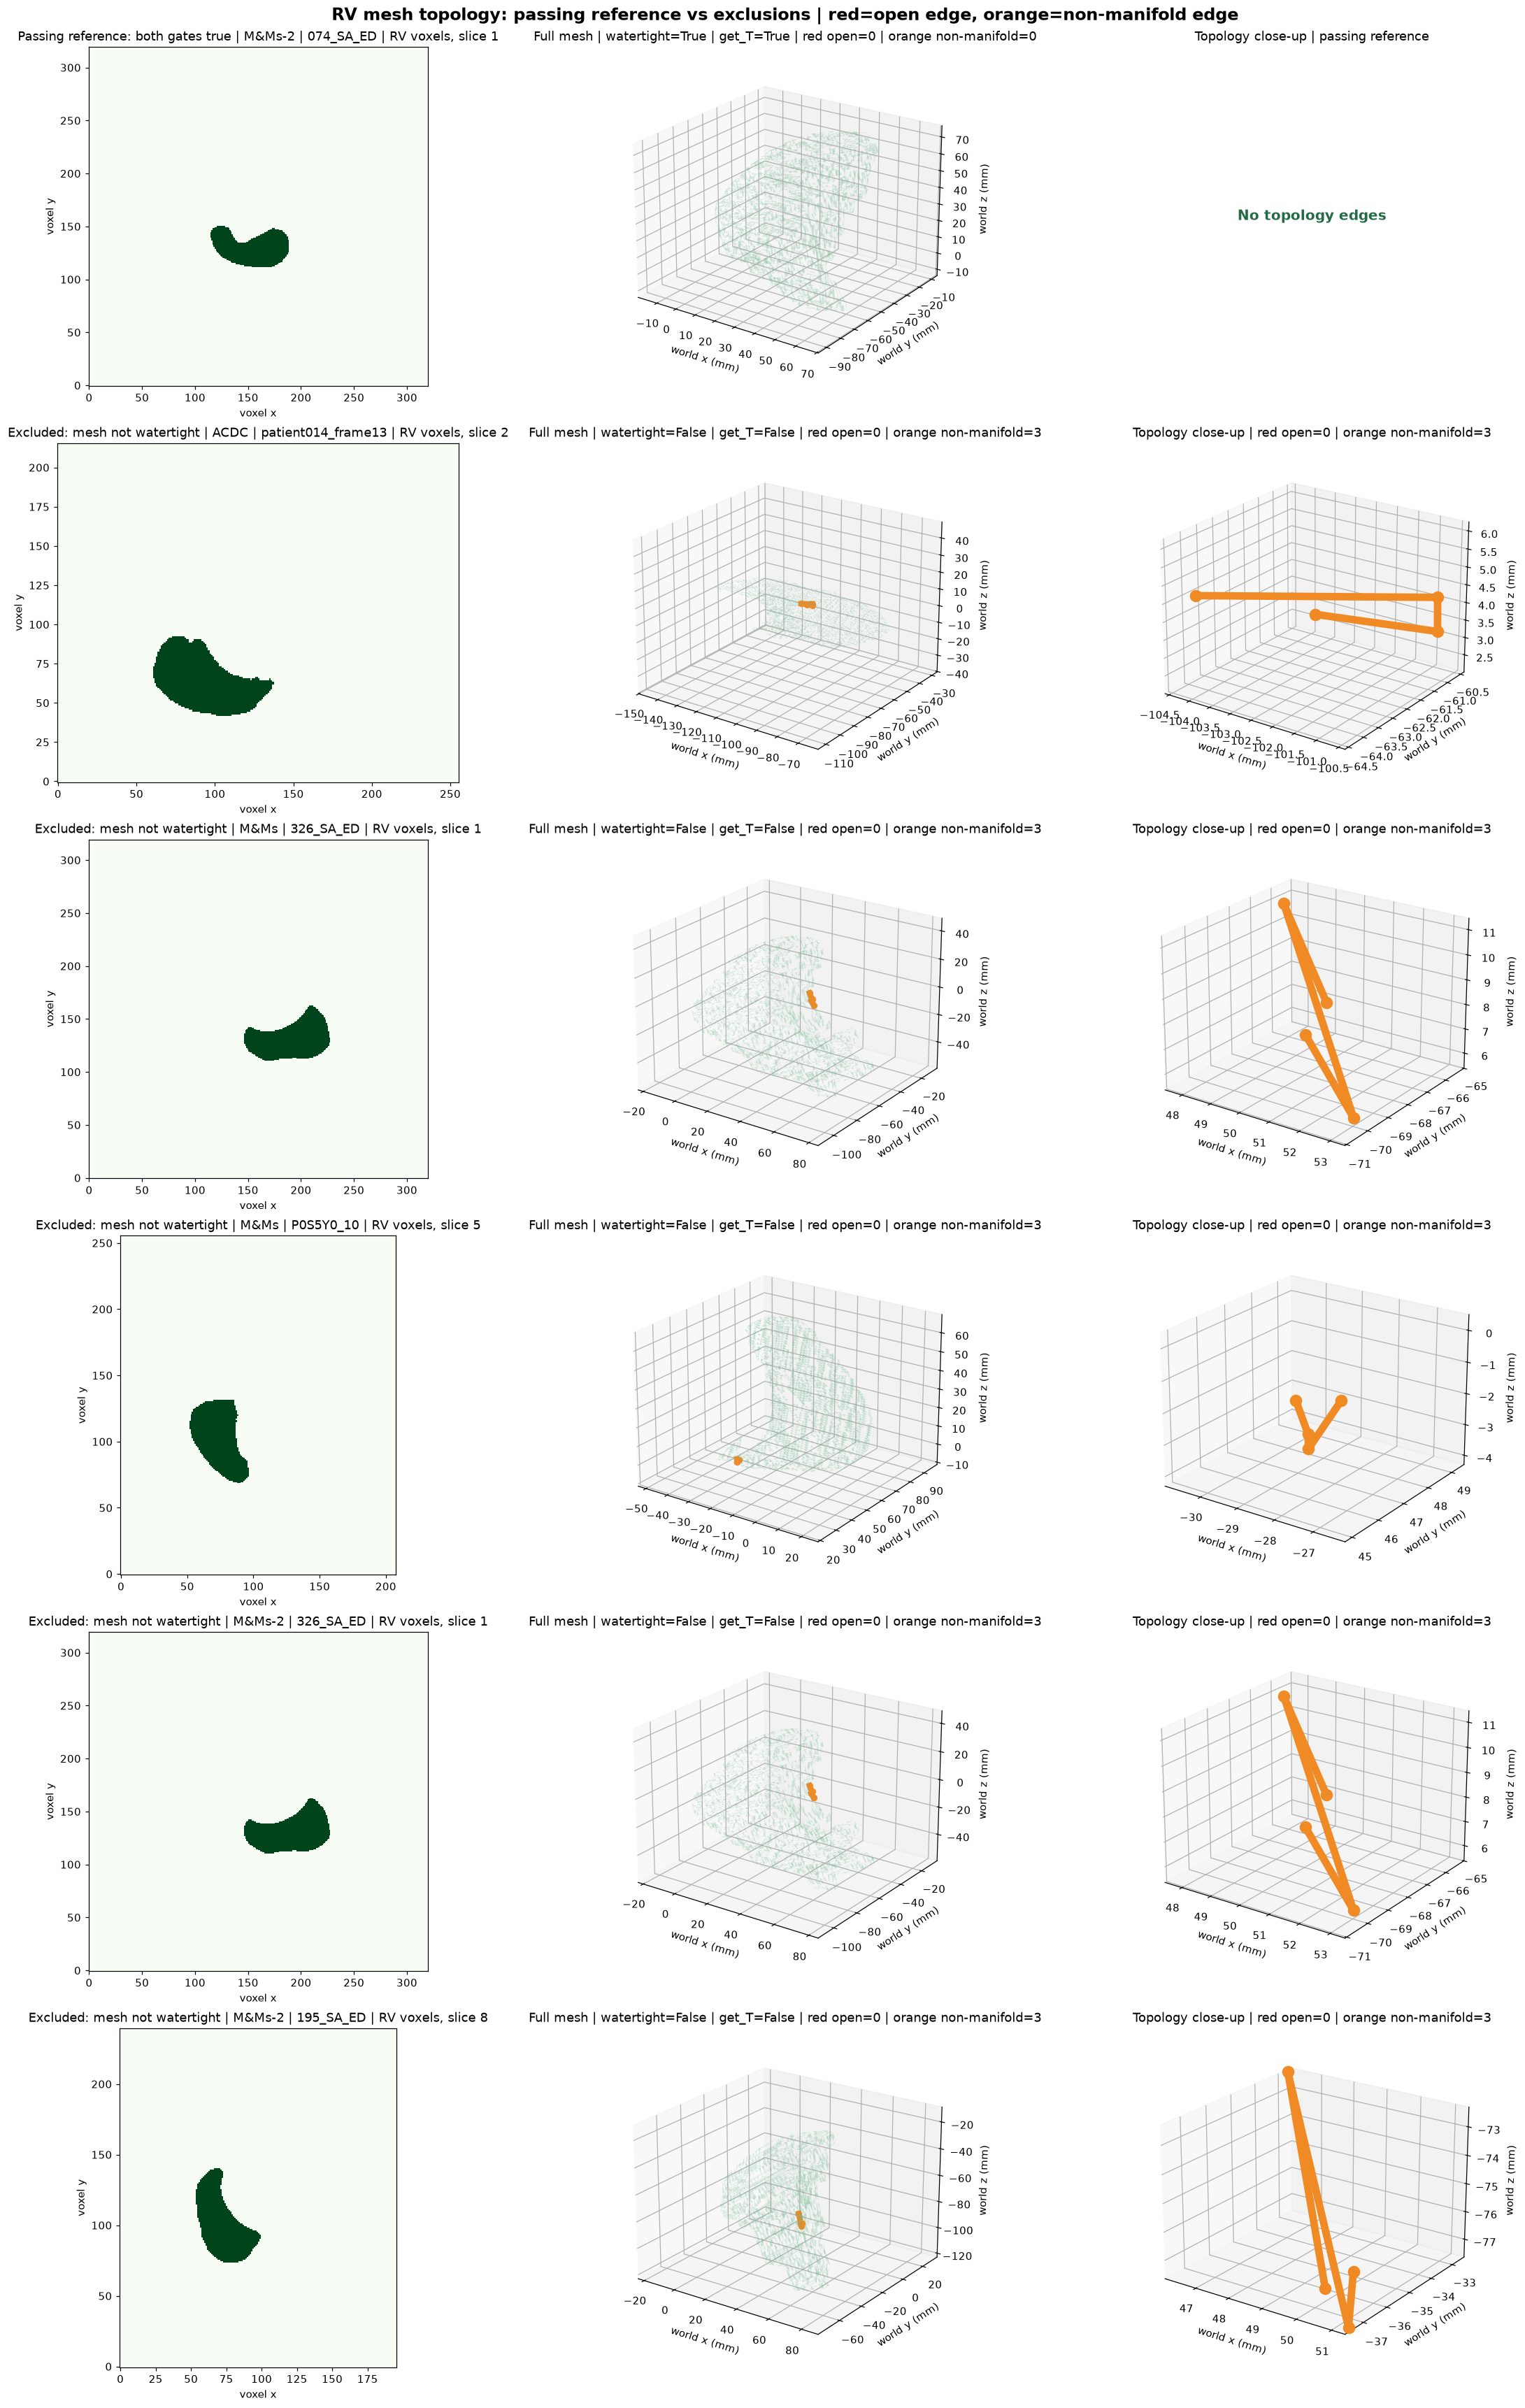

Passing reference: M&Ms-2 | 074_SA_ED
Failure topology: 0 open boundary edges and 3 non-manifold edges for each excluded mesh
Saved visual review: E:\Jy\visheart-rv-4d-notebook\outputs\full_real_getT_audit\watertight_mesh_topology_comparison_gallery.png


In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import trimesh
from IPython.display import Image, display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy import ndimage
from skimage import measure

AUDIT_DIR = Path(globals().get("NB_ROOT", Path.cwd())) / "outputs" / "full_real_getT_audit"
REVIEW_MANIFEST = AUDIT_DIR / "visual_review_manifest.csv"
FULL_AUDIT = AUDIT_DIR / "full_real_getT_audit.csv"
OUTPUT_IMAGE = AUDIT_DIR / "watertight_mesh_topology_comparison_gallery.png"
RV_LABEL = 1
MIN_COMPONENT_VOXELS = 32


def _main_component(binary):
    components, count = ndimage.label(binary)
    if count == 0:
        return binary
    sizes = ndimage.sum(binary, components, range(1, count + 1))
    keep = np.arange(1, count + 1)[sizes >= MIN_COMPONENT_VOXELS]
    if not len(keep):
        keep = np.array([int(np.argmax(sizes)) + 1])
    return np.isin(components, keep)


def _rv_mesh(labels, affine):
    binary = ndimage.binary_closing(_main_component(labels == RV_LABEL), iterations=1)
    padded = np.pad(binary.astype(np.float32), 1, mode="constant")
    vertices, faces, _, _ = measure.marching_cubes(padded, level=0.5)
    vertices -= 1.0
    world = (np.c_[vertices, np.ones(len(vertices))] @ affine.T)[:, :3]
    mesh = trimesh.Trimesh(vertices=world, faces=faces, process=False)
    trimesh.smoothing.filter_taubin(mesh, iterations=1)
    return binary, mesh


def _topology_edges(mesh):
    edges = np.sort(mesh.edges.reshape(-1, 2), axis=1)
    unique_edges, counts = np.unique(edges, axis=0, return_counts=True)
    return unique_edges[counts == 1], unique_edges[counts > 2]


def _equal_3d_axes(axis, vertices):
    lower, upper = vertices.min(axis=0), vertices.max(axis=0)
    center = (lower + upper) / 2
    radius = max(upper - lower) / 2
    radius = max(radius, 1.0)
    axis.set_xlim(center[0] - radius, center[0] + radius)
    axis.set_ylim(center[1] - radius, center[1] + radius)
    axis.set_zlim(center[2] - radius, center[2] + radius)


with REVIEW_MANIFEST.open(encoding="utf-8") as handle:
    failures = [row for row in csv.DictReader(handle) if row["reason"] == "RV mesh is not watertight"]

with FULL_AUDIT.open(encoding="utf-8") as handle:
    passing = [
        row for row in csv.DictReader(handle)
        if row["watertight"] == "True" and row["get_T"] == "True"
    ]

if not failures or not passing:
    raise RuntimeError("The visual audit needs both non-watertight exclusions and passing shapes")

# Fixed seed makes the reference stable and therefore comparable across reruns.
reference = passing[int(np.random.default_rng(20260823).integers(len(passing)))]
cases = [{"case_role": "Passing reference: both gates true", **reference}]
cases += [{"case_role": "Excluded: mesh not watertight", **failure} for failure in failures]

figure = plt.figure(figsize=(20.5, 5.2 * len(cases)), constrained_layout=True)
for index, row in enumerate(cases):
    image = nib.load(row["path"])
    labels = np.asarray(image.dataobj)
    if labels.ndim == 4 and labels.shape[3] == 1:
        labels = labels[..., 0]
    binary, mesh = _rv_mesh(labels.astype(np.int16, copy=False), image.affine)
    open_edges, non_manifold_edges = _topology_edges(mesh)
    topology_points = (
        mesh.vertices[np.unique(np.vstack((open_edges, non_manifold_edges)))]
        if len(open_edges) or len(non_manifold_edges) else np.empty((0, 3))
    )
    slice_index = int(np.argmax(binary.sum(axis=(0, 1))))

    slice_axis = figure.add_subplot(len(cases), 3, index * 3 + 1)
    slice_axis.imshow(binary[:, :, slice_index].T, origin="lower", cmap="Greens", interpolation="nearest")
    slice_axis.set_title(
        f"{row['case_role']} | {row['dataset']} | {row['shape']} | RV voxels, slice {slice_index}"
    )
    slice_axis.set_xlabel("voxel x")
    slice_axis.set_ylabel("voxel y")

    mesh_axis = figure.add_subplot(len(cases), 3, index * 3 + 2, projection="3d")
    faces = mesh.faces
    if len(faces) > 2500:
        faces = faces[np.linspace(0, len(faces) - 1, 2500, dtype=int)]
    triangles = mesh.vertices[faces]
    mesh_axis.add_collection3d(
        Poly3DCollection(triangles, facecolor="#70b88c", edgecolor="none", alpha=0.28)
    )
    for edge in open_edges:
        points = mesh.vertices[edge]
        mesh_axis.plot(points[:, 0], points[:, 1], points[:, 2], color="#d13b31", linewidth=4.0)
    for edge in non_manifold_edges:
        points = mesh.vertices[edge]
        mesh_axis.plot(points[:, 0], points[:, 1], points[:, 2], color="#f08a24", linewidth=5.0)
    if len(topology_points):
        mesh_axis.scatter(
            topology_points[:, 0], topology_points[:, 1], topology_points[:, 2],
            color="#f08a24", s=26, depthshade=False,
        )
    _equal_3d_axes(mesh_axis, mesh.vertices)
    mesh_axis.view_init(elev=22, azim=-55)
    mesh_axis.set_title(
        f"Full mesh | watertight={mesh.is_watertight} | get_T={row['get_T']} "
        f"| red open={len(open_edges)} | orange non-manifold={len(non_manifold_edges)}"
    )
    mesh_axis.set_xlabel("world x (mm)")
    mesh_axis.set_ylabel("world y (mm)")
    mesh_axis.set_zlabel("world z (mm)")

    detail_axis = figure.add_subplot(len(cases), 3, index * 3 + 3, projection="3d")
    if len(topology_points):
        for edge in open_edges:
            points = mesh.vertices[edge]
            detail_axis.plot(points[:, 0], points[:, 1], points[:, 2], color="#d13b31", linewidth=5.0)
        for edge in non_manifold_edges:
            points = mesh.vertices[edge]
            detail_axis.plot(points[:, 0], points[:, 1], points[:, 2], color="#f08a24", linewidth=7.0)
        detail_axis.scatter(
            topology_points[:, 0], topology_points[:, 1], topology_points[:, 2],
            color="#f08a24", s=110, depthshade=False,
        )
        _equal_3d_axes(detail_axis, topology_points)
        detail_axis.view_init(elev=22, azim=-55)
        detail_axis.set_title(
            f"Topology close-up | red open={len(open_edges)} | orange non-manifold={len(non_manifold_edges)}"
        )
        detail_axis.set_xlabel("world x (mm)")
        detail_axis.set_ylabel("world y (mm)")
        detail_axis.set_zlabel("world z (mm)")
    else:
        detail_axis.text2D(
            0.5, 0.5, "No topology edges", transform=detail_axis.transAxes,
            ha="center", va="center", color="#236b45", fontsize=13, fontweight="bold",
        )
        detail_axis.set_title("Topology close-up | passing reference")
        detail_axis.set_axis_off()

figure.suptitle("RV mesh topology: passing reference vs exclusions | red=open edge, orange=non-manifold edge", fontsize=16, fontweight="bold")
figure.savefig(OUTPUT_IMAGE, dpi=110, bbox_inches="tight")
plt.show()
print(f"Saved visual review: {OUTPUT_IMAGE}")
display(Image(filename=str(OUTPUT_IMAGE)))
